# Introduction

This notebook walks throught the production of Fig. S01, which plots the percent difference in $H_s$, $T_{0m1}$, and $U_s$ between WW3-HVWD, WW3-LVWD&CUR, and WW3-HVWD&CUR relative to WW3-LVWD for a representative model snapshot.

## Imports

In [54]:
import sys
sys.path.append("../src")

In [55]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from map_plot import (
    subset,
    add_circle_to_axes,
    make_three_panel_money_figure,
)

plt.rcdefaults()
plt.style.use("../src/paper.mplstyle")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data

We use the raw WAVEWATCH III (WW3) output to plot these maps.

In [56]:
data_path = Path('../data/raw_ww3/')

We open the output for the four main suite of simulations: WW3-LVWD, WW3-HVWD, WW3-LVWD&CUR, and WW3-HVWD&CUR. See Table 1 in the manuscript for more information on these simulations.

In [58]:
ww3_lvwd = xr.open_dataset(data_path / 'lvwd.nc')
ww3_hvwd = xr.open_dataset(data_path / 'hvwd.nc')
ww3_lvwd_cur = xr.open_dataset(data_path / 'lvwd_cur.nc')
ww3_hvwd_cur = xr.open_dataset(data_path / 'hvwd_cur.nc')

November 30, 2020 at 16:00 UTC was found to demonstrate both wind- and current-driven variability in the Stokes drift effectively. The spatial extent is nearly as large as the model domain, but is is cropped to be square, which is better for plotting.

In [59]:
timestep = '2020-11-30T16:00:00.000000000'

lons = slice(None, 240)
lats = slice(25, 45)

In [60]:
ww3_lvwd_plt = subset(ww3_lvwd, timestep, lons, lats)
ww3_hvwd_plt = subset(ww3_hvwd, timestep, lons, lats)
ww3_lvwd_cur_plt = subset(ww3_lvwd_cur, timestep, lons, lats)
ww3_hvwd_cur_plt = subset(ww3_hvwd_cur, timestep, lons, lats)

We close the datasets we are not using anymore to be kind to our workstation memory.

In [61]:
ww3_lvwd.close(); del ww3_lvwd
ww3_hvwd.close(); del ww3_hvwd
ww3_lvwd_cur.close(); del ww3_lvwd_cur
ww3_hvwd_cur.close(); del ww3_hvwd_cur

# Variables to Plot

This figure plots 1 variable per row, three rows total: $H_s$, $T_{0m1}$, and $U_s$. For each column, we compute the percent difference between the fields in the WW3-HVWD, WW3-LVWD&CUR, or WW3-HVWD&CUR relative to the WW3-LVWD configuration. For the Stokes drift, we compute the percent differnce in the magnitude.

In [62]:
Hs_lvwd = ww3_lvwd_plt.hs
Hs_hvwd = ww3_hvwd_plt.hs
Hs_lvwd_cur = ww3_lvwd_cur_plt.hs
Hs_hvwd_cur = ww3_hvwd_cur_plt.hs

In [63]:
T0m1_lvwd = ww3_lvwd_plt.t0m1
T0m1_hvwd = ww3_hvwd_plt.t0m1
T0m1_lvwd_cur = ww3_lvwd_cur_plt.t0m1
T0m1_hvwd_cur = ww3_hvwd_cur_plt.t0m1

In [64]:
Us_lvwd = np.hypot(ww3_lvwd_plt.uuss, ww3_lvwd_plt.vuss)
Us_hvwd = np.hypot(ww3_hvwd_plt.uuss, ww3_hvwd_plt.vuss)
Us_lvwd_cur = np.hypot(ww3_lvwd_cur_plt.uuss, ww3_lvwd_cur_plt.vuss)
Us_hvwd_cur = np.hypot(ww3_hvwd_cur_plt.uuss, ww3_hvwd_cur_plt.vuss)

Percent increase relative to the baseline is computed as

$$
\%\,\mathrm{increase}
=
\frac{\mathrm{enhanced} - \mathrm{baseline}}
{\mathrm{baseline}}
\times 100,
$$
where the enhanced field has more spatial variability and the baseline is the smooth field.

In [65]:
def pct_incease(baseline, enhanced):
    return ((enhanced - baseline) / baseline) * 100

In [66]:
Hs_hvwd_diff = pct_incease(Hs_lvwd, Hs_hvwd)
Hs_lvwd_cur_diff = pct_incease(Hs_lvwd, Hs_lvwd_cur)
Hs_hvwd_cur_diff = pct_incease(Hs_lvwd, Hs_hvwd_cur)

In [67]:
T0m1_hvwd_diff = pct_incease(T0m1_lvwd, T0m1_hvwd)
T0m1_lvwd_cur_diff = pct_incease(T0m1_lvwd, T0m1_lvwd_cur)
T0m1_hvwd_cur_diff = pct_incease(T0m1_lvwd, T0m1_hvwd_cur)

In [68]:
Us_hvwd_diff = pct_incease(Us_lvwd, Us_hvwd)
Us_lvwd_cur_diff = pct_incease(Us_lvwd, Us_lvwd_cur)
Us_hvwd_cur_diff = pct_incease(Us_lvwd, Us_hvwd_cur)

# Plotting

In [69]:
figS01_ranges = {
    "stokes_diff_pct": {
        "levels": np.linspace(-10, 10, 30),
        "ticks": [-10,0,10],
        "extend": "both",
    },
    "hs_diff_pct": {
        "levels": np.linspace(-10, 10, 30),
        "ticks": [-10,0,10],
        "extend": "both",
    },
    "T0m1_diff_pct": {
        "levels": np.linspace(-10, 10, 30),
        "ticks": [-10,0,10],
        "extend": "both",
    },
}

In [70]:
row1 = [
    {
        "data": Hs_hvwd_diff,
        "title": r"(WW3-HVWD) $–$ (WW3-LVWD)",
        "style": "hs_diff_pct",
    },
    {
        "data": Hs_lvwd_cur_diff,
        "title": r"(WW3-LVWD&CUR) $–$ (WW3-LVWD)",
        "style": "hs_diff_pct",
    },
    {
        "data": Hs_hvwd_cur_diff,
        "title": r"(WW3-HVWD&CUR) $–$ (WW3-LVWD)",
        "style": "hs_diff_pct",
    },
]

In [71]:
row2 = [
    {
        "data": T0m1_hvwd_diff,
        "title": r"",
        "style": "T0m1_diff_pct",
    },
    {
        "data": T0m1_lvwd_cur_diff,
        "title": r"",
        "style": "T0m1_diff_pct",
    },
    {
        "data": T0m1_hvwd_cur_diff,
        "title": r"",
        "style": "T0m1_diff_pct",
    },
]

In [72]:
row3 = [
    {
        "data": Us_hvwd_diff,
        "title": r"",
        "style": "stokes_diff_pct",
    },
    {
        "data": Us_lvwd_cur_diff,
        "title": r"",
        "style": "stokes_diff_pct",
    },
    {
        "data": Us_hvwd_cur_diff,
        "title": r"",
        "style": "stokes_diff_pct",
    },
]

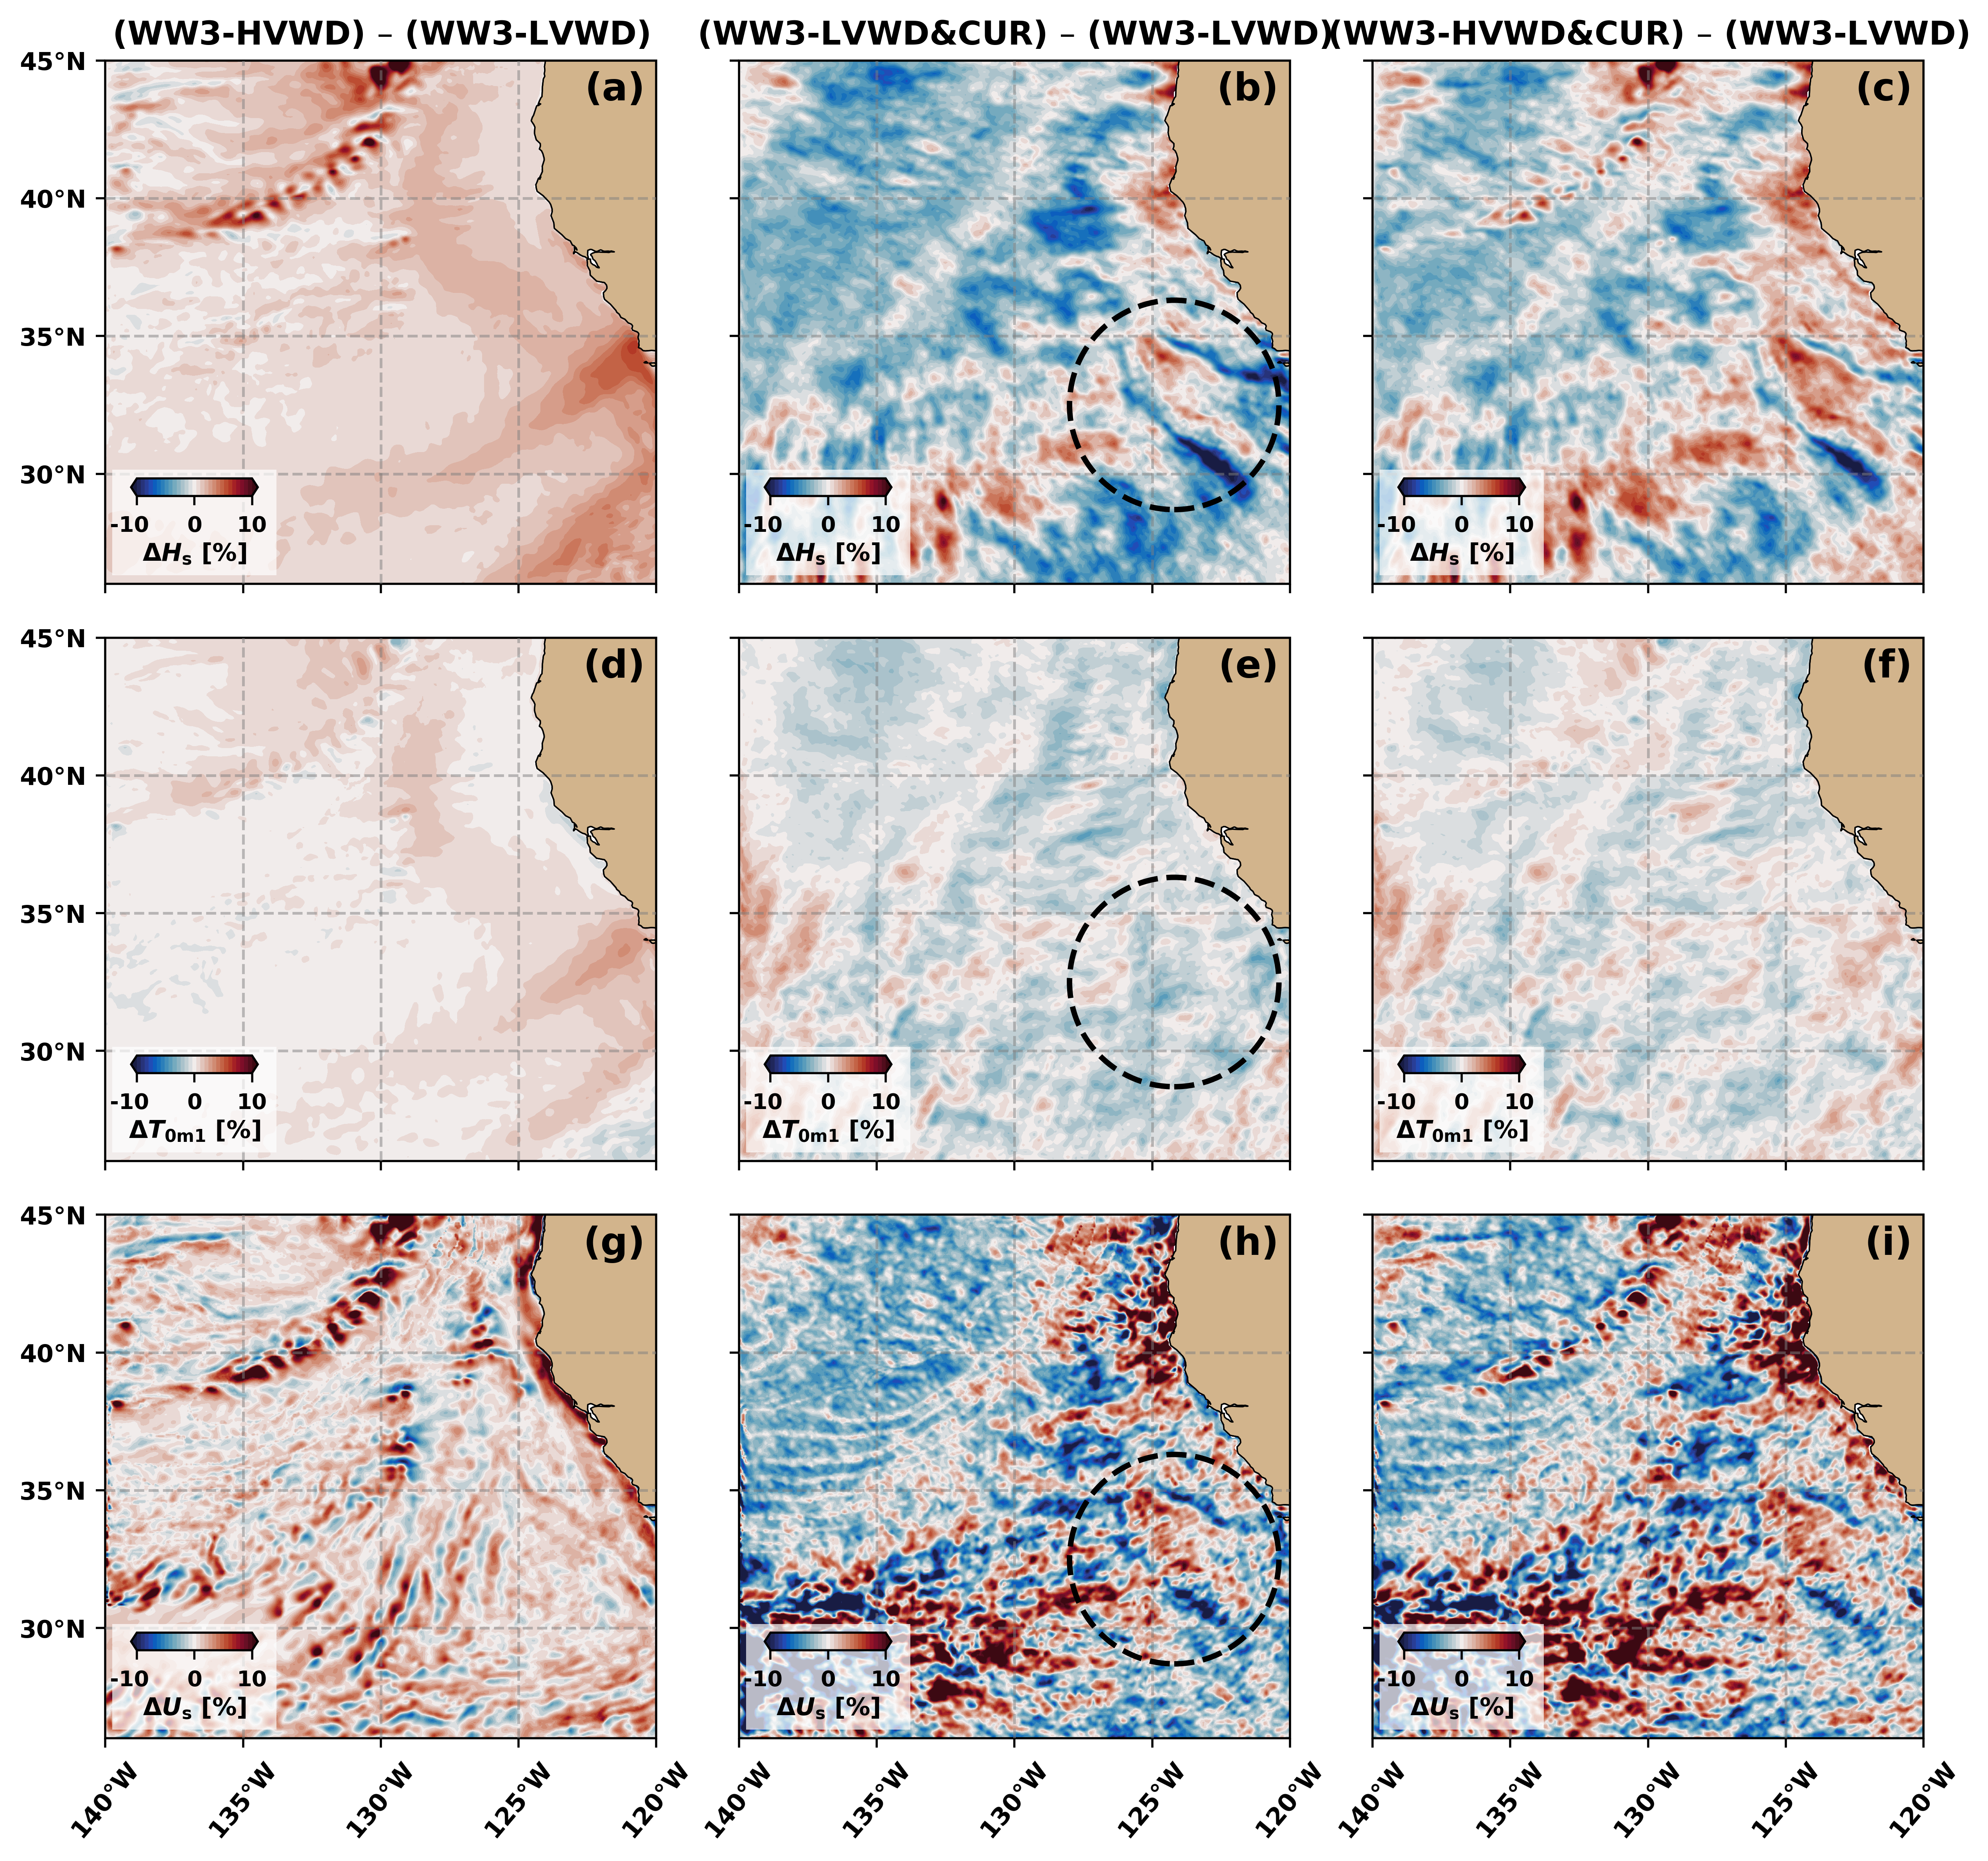

In [73]:
fig, axes = make_three_panel_money_figure(
    three_panel_rows=[
        row1,
        row2,
        row3,
    ],
    ranges=figS01_ranges,
    extent=[-140, -120, 26, 45],
)

add_circle_to_axes(axes[0][1], center_lon=235.8, center_lat=32.5, radius=3.8, color='k')
add_circle_to_axes(axes[1][1], center_lon=235.8, center_lat=32.5, radius=3.8, color='k')
add_circle_to_axes(axes[2][1], center_lon=235.8, center_lat=32.5, radius=3.8, color='k')

for row in axes:
    for ax in row:
        ax.title.set_fontsize(12)
        ax.title.set_fontweight("bold")

plt.show()

In [74]:
fig.savefig(
    '../figures/figS01.png',
    dpi=500,
    bbox_inches='tight',
    pad_inches=0.1,
)